In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from scipy.stats import linregress
import scipy.sparse as sp

Tissue = "Region1"
TableFolder = "REGION1_TABLES"


adata = sc.read_h5ad(f"/Volumes/ProstateCancerEvoMain/dbs/Ongoing/{Tissue}/{TableFolder}/{Tissue}_Xenium_Phen_HE_Integrated.Xenium_Native_Table.Phen_and_ImagePropsEnriched.V2.h5ad")
adata

adata_for_annotation = sc.read_h5ad(f"/Volumes/ProstateCancerEvoMain/dbs/Completed/AllRegions/{Tissue}.raw.annotated.V2.h5ad")
adata.obs["assigned_celltype_L0"] = adata_for_annotation.obs["assigned_celltype_L0"].values

In [61]:
mask = adata.obs["assigned_celltype_L0"] == "tumor_cell_markers"
adata = adata[mask, :].copy()
adata

AnnData object with n_obs × n_vars = 56454 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'DAPI_PhenCyc', 'CD8_PhenCyc', 'CD31_PhenCyc', 'CD11c_PhenCyc', 'CD34_PhenCyc', 'CD20_PhenCyc', 'CD4_PhenCyc', 'CD21_PhenCyc', 'Ki67_PhenCyc', 'CD68_PhenCyc', 'E_cadherin_PhenCyc', 'pten_PhenCyc', 'NF-H_PhenCyc', 'FOXp3_PhenCyc', 'CD45_PhenCyc', 'TFAM_PhenCyc', 'PDL-1_PhenCyc', 'SOX2_PhenCyc', 'Vimentin_PhenCyc', 'HIF1A_PhenCyc', 'CD44_PhenCyc', 'Keratin_8_18_PhenCyc', 'aSMA_PhenCyc', 'EpCAM_PhenCyc', 'K14_PhenCyc', 'area', 'centroid-0', 'centroid-1', 'centroid_local-1', 'centroid_weighted_local-0', 'centroid_weighted_local-1', 'euler_number', 'extent', 'feret_diameter_max', 'intensity_max', 'intensity_min', 'intensity_mean', 'solidity', 'eccentricity', 'per

In [62]:
features = [
    'area', 'extent', 'feret_diameter_max',
    'solidity', 'eccentricity', 'perimeter',
    'equivalent_diameter_area', 'cell_area', 'nucleus_area'
]

In [43]:

# coerce to numeric (errors → NaN)
#df = adata.obs[features].apply(pd.to_numeric, errors='coerce')

# set up 3×3 grid
#fig, axes = plt.subplots(3, 3, figsize=(15, 12))
#axes = axes.flatten()

# for ax, feat in zip(axes, features):
#     vals = df[feat].dropna()
#     ax.hist(vals, bins=30, edgecolor='black')
#     ax.set_title(f'Distribution of {feat}')
#     ax.set_xlabel(feat)
#     ax.set_ylabel('Count')

# fig.tight_layout()
# plt.show()

In [ ]:
X = adata.X

if hasattr(X, "toarray"):
    total_counts = np.array(X.toarray()).sum(axis=1)
else:
    total_counts = np.array(X).sum(axis=1)
adata.obs['total_counts'] = total_counts


plot_feats = [f for f in features if f in adata.obs.columns][:9]

df = adata.obs[plot_feats].apply(pd.to_numeric, errors='coerce')
df['total_counts'] = adata.obs['total_counts']

In [45]:
# x = np.array(adata.X.toarray()).sum(axis=1)   # shape (n_cells,)
# y = np.asarray(adata.obs["cell_area"])


# y_Tsize = x/y 
# slope, intercept, r_value, p_value, std_err = linregress(x, y_Tsize)
# x_line = np.linspace(min(x), max(x), 100)
# y_line = slope * x_line + intercept

# # Plot using matplotlib
# fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(x, y_Tsize, alpha=0.6, s=30, label='Data')
# ax.plot(x_line, y_line, color='red', linewidth=2, label=f'Fit: y = {slope:.4f}x + {intercept:.2f}')

# # Annotation
# annotation_text = f"Slope: {slope:.4f}\nIntercept: {intercept:.2f}"
# ax.text(0.05, 0.95, annotation_text, transform=ax.transAxes,
#         fontsize=12, verticalalignment='top',
#         bbox=dict(facecolor='white', alpha=0.7))

# # Labels and title
# ax.set_xlabel("Expression (x)")
# ax.set_ylabel("Cell Area / Total Transcript")
# ax.set_title("Scatter of Expression vs. Adjusted Cell Area")
# ax.legend()
# plt.tight_layout()
# plt.show()

In [64]:
expr = adata.X

if hasattr(expr, "toarray"):
    T = np.array(expr.toarray()).sum(axis=1)
else:
    T = np.asarray(expr.sum(axis=1)).ravel()

y = adata.obs["cell_area"].values


records = []
for goi in adata.var_names:
    
    x = np.asarray(adata[:, goi].X.toarray().flatten())
    if np.unique(x).size > 5:
        print(goi)
        # 2) define mask properly (discard zero-expression cells)
        mask = x > 0

        # 3) Option 3: use masked T and y
        T_y =  T / y
        x2, y2 = x[mask], T_y[mask]

        try:
            slope, intercept, r_value, p_value, std_err = linregress(x2, y2)

            # 95% CI for slope under normal approximation:
            ci_low  = slope - 1.96 * std_err
            ci_high = slope + 1.96 * std_err

            # validation: CI does *not* cross zero
            validation = (ci_low > 0) or (ci_high < 0)

            records.append({
            "goi":          goi,
            "slope":        slope,
            "intercept":    intercept,
            "p_value":      p_value,
            "r_value":      r_value,
            "std_err":      std_err,
            "ci_low":       ci_low,
            "ci_high":      ci_high,
            "validation":   validation
            })
        except:
            pass

AAMP
ABAT
ABCC1
ABCC4
ACACA
ACE
ACLY
ACPP
ACTN4
ADAM10
ADAM9
ADAMTS1
ADAR
ADD1
ADGRA3
ADIPOR1
ADM
ADNP
ADRA2A
ADRB1
AGTR1
AHCY
AIMP2
AKAP11
AKT1
AKT2
AKT3
ALCAM
ALDH3A2
ALDH7A1
ALDOA
ALG13
ALG2
ALKBH5
ALPL
AMACR
ANGPTL2
ANGPTL7
ANKRD13A
ANPEP
ANXA1
ANXA2
ANXA3
ANXA5
AP1B1
AP1S3
AP2M1
AP3D1
APEX1
APH1B
API5
APMAP
APOL1
APOL2
APP
ARC
ARF1
ARF6
ARG2
ARHGAP35
ARL8B
ARRB2
ARRDC3
ASCC3
ASCL1
ASTN2
ATF3
ATF4
ATF6
ATG5
ATL3
ATP1A1
ATP2A2
ATP5F1A
ATP5F1C
ATPAF1
ATRX
ATXN2L
ATXN3
B2M
B4GAT1
BACE2
BAG6
BARX2
BCAM
BCCIP
BCL10
BCL2L1
BCL2L2
BCL3
BCOR
BECN1
BHLHE40
BIK
BIRC5
BMI1
BMPR1A
BMPR1B
BMPR2
BNIP3
BRD3
BRD4
BSDC1
C1QBP
C4A
C4B
CACNA1D
CACUL1
CADM4
CALM3
CAMK1
CANX
CASP7
CAT
CBFB
CBWD2
CBX1
CBX3
CCDC43
CCDC50
CCDC6
CCL2
CCL20
CCL5
CCN1
CCN2
CCN3
CCND1
CCNO
CCT2
CCT3
CCT5
CCT6A
CCT7
CCT8
CD177
CD276
CD2AP
CD302
CD44
CD46
CD47
CD59
CD99
CDC42
CDH1
CDH3
CDK7
CDKN1A
CDKN1B
CDV3
CEACAM1
CFB
CFDP1
CGNL1
CHD3
CHI3L2
CHKA
CKAP4
CKS2
CLCN3
CLDN1
CLDN7
CLGN
CLIC4
CLOCK
CLPTM1L
CLSTN1
CLTC
CNNM3
CNOT1
C

In [47]:
df = pd.DataFrame(records)
df = df[df["validation"] == True]
df.sort_values(by="slope")

,goi,slope,intercept,p_value,r_value,std_err,ci_low,ci_high,validation
192,CST2,-0.370321,3.117241,3.269996e-03,-0.201120,0.124465,-0.614273,-0.126369,True
411,HSPB8,-0.360971,3.943950,4.036819e-02,-0.080246,0.175735,-0.705412,-0.016531,True
606,PAM,-0.237584,3.934409,5.049554e-45,-0.116839,0.016816,-0.270543,-0.204625,True
187,CRYBG3,-0.180478,4.272661,8.578514e-04,-0.050054,0.054105,-0.286524,-0.074432,True
758,SCGN,-0.179778,3.450284,3.582084e-05,-0.065046,0.043450,-0.264941,-0.094615,True
...,...,...,...,...,...,...,...,...,...
627,PELP1,0.373698,4.117491,6.018369e-11,0.086291,0.057003,0.261973,0.485423,True
493,LRPPRC,0.375359,3.889678,8.576620e-25,0.109025,0.036400,0.304016,0.446702,True
532,MRPL45,0.383723,3.920151,7.402292e-12,0.089863,0.055905,0.274150,0.493296,True
934,TP53,0.394702,4.109504,5.316694e-11,0.097654,0.060004,0.277094,0.512311,True


In [48]:
from statsmodels.stats.multitest import multipletests

n_tests = len(df)
reject, p_bonf, _, _ = multipletests(df['p_value'], alpha=0.05, method='bonferroni')

df['p_bonf']        = p_bonf
df['sig_bonferroni'] = reject

print(f"{df['sig_bonferroni'].sum()} genes significant after Bonferroni correction")

df[df['sig_bonferroni']].sort_values('slope')

df = df[df["sig_bonferroni"] == True]
df


605 genes significant after Bonferroni correction


,goi,slope,intercept,p_value,r_value,std_err,ci_low,ci_high,validation,p_bonf,sig_bonferroni
0,AAMP,0.205672,4.013311,1.106563e-08,0.057736,0.035966,0.135178,0.276167,True,8.874635e-06,True
2,ABCC1,0.318914,4.192140,5.529084e-21,0.116211,0.033815,0.252635,0.385192,True,4.434326e-18,True
3,ABCC4,0.154750,4.120131,4.717771e-46,0.117136,0.010825,0.133534,0.175967,True,3.783653e-43,True
4,ACACA,0.250512,3.883012,5.327014e-118,0.153235,0.010783,0.229378,0.271647,True,4.272265e-115,True
6,ACLY,0.262175,3.928072,4.973475e-46,0.112377,0.018349,0.226211,0.298139,True,3.988727e-43,True
...,...,...,...,...,...,...,...,...,...,...,...
1011,YY1,0.134561,4.017218,1.268461e-05,0.041189,0.030810,0.074173,0.194949,True,1.017306e-02,True
1013,ZCCHC17,0.174251,3.988805,4.557173e-06,0.049159,0.037987,0.099797,0.248706,True,3.654853e-03,True
1014,ZFAND5,0.201860,3.914017,1.876467e-20,0.081596,0.021741,0.159248,0.244472,True,1.504927e-17,True
1017,ZNF106,0.181622,4.024901,1.715767e-07,0.056589,0.034713,0.113585,0.249660,True,1.376045e-04,True


In [49]:
df[df["slope"] < 0]

,goi,slope,intercept,p_value,r_value,std_err,ci_low,ci_high,validation,p_bonf,sig_bonferroni
126,CCN3,-0.123353,3.549757,9.407164e-11,-0.075180,0.019020,-0.160632,-0.086075,True,7.544545e-08,True
135,CD177,-0.149772,3.633576,1.231410e-18,-0.092432,0.016960,-0.183014,-0.116531,True,9.875910e-16,True
142,CD59,-0.170546,3.919252,7.223374e-13,-0.065209,0.023743,-0.217083,-0.124010,True,5.793146e-10,True
326,FOLH1,-0.012379,3.739907,5.138396e-07,-0.027324,0.002465,-0.017210,-0.007548,True,4.120993e-04,True
606,PAM,-0.237584,3.934409,5.049554e-45,-0.116839,0.016816,-0.270543,-0.204625,True,4.049742e-42,True
746,RNF187,-0.085842,4.020889,9.280684e-07,-0.036609,0.017490,-0.120123,-0.051561,True,7.443108e-04,True
758,SCGN,-0.179778,3.450284,3.582084e-05,-0.065046,0.043450,-0.264941,-0.094615,True,2.872831e-02,True
760,SDC2,-0.103915,3.905796,7.179124e-15,-0.064271,0.013340,-0.130062,-0.077768,True,5.757658e-12,True
779,SESN3,-0.158298,3.889874,8.021216e-08,-0.053997,0.029474,-0.216068,-0.100528,True,6.433015e-05,True
839,SOD3,-0.110878,3.905073,3.196038e-07,-0.053321,0.021676,-0.153362,-0.068393,True,2.563222e-04,True


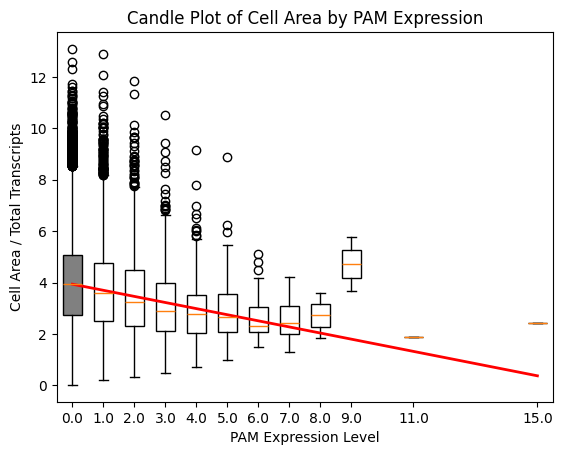

In [52]:
import numpy as np
import matplotlib.pyplot as plt

goi = "PAM"
x = np.array(adata[:, goi].X.toarray()).ravel()
y = adata.obs["cell_area"].values
y2 = T / y

uniq_levels = np.unique(x)
groups = [y2[x == lvl] for lvl in uniq_levels]

fig, ax = plt.subplots()
# Enable patch_artist so boxes are Patch objects
bp = ax.boxplot(groups,
                positions=uniq_levels,
                widths=0.6,
                patch_artist=True)

# Color the box at x=0 gray
for lvl, box in zip(uniq_levels, bp['boxes']):
    if lvl == 0:
        box.set_facecolor('gray')
    else:
        box.set_facecolor('white')  # or any other default


slope = df.loc[df['goi'] == goi, 'slope'].values[0]
intercept = df.loc[df['goi'] == goi, 'intercept'].values[0]
x_line = np.linspace(uniq_levels.min(), uniq_levels.max(), 100)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color='red',linewidth=2, label=f'y = {slope:.2f}x + {intercept:.2f}')
ax.set_xlabel(f"{goi} Expression Level")
ax.set_ylabel("Cell Area / Total Transcripts")
ax.set_title(f"Candle Plot of Cell Area by {goi} Expression")
plt.show()